Authors: Zhewei Yao <https://github.com/yaozhewei>, Amir Gholami <http://amirgholami.org/>


This tutorial shows how to compute the Hessian information using (randomized) numerical linear algebra for both explicit Hessian (the matrix is given) as well as implicit Hessian (the matrix is ungiven).

We'll start by doing the necessary imports:

In [1]:
import numpy as np
import torch 
from torchvision import datasets, transforms
from utils import * # get the dataset
from pyhessian import hessian # Hessian computation
from density_plot import get_esd_plot # ESD plot

import ase.data
import ase.io
import numpy as np
import torch

from mace import data
from mace.tools import torch_geometric, torch_tools, utils

from mace.modules import WeightedEnergyForcesLoss

import matplotlib.pyplot as plt
%matplotlib inline

/home/jerry528/miniconda3/envs/mace-finetune/lib/python3.10/site-packages/kfac/base_preconditioner.py:15: UserWarning: NVIDIA Apex is not installed or was not installed with --cpp_ext. Falling back to PyTorch flatten and unflatten.
  from kfac.distributed import get_rank


In [2]:
# enable cuda devices
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="0"
device = "cpu"
model_path = "/scratch/st-ortner-1/jerry528/ETN/results_MACE3bpa_2layers_new/3bpa-non_symmetric_cp-L0-seed-5-c128/MACE3bpa_baseline_run-5.model"
config_path = "/scratch/st-ortner-1/jerry528/ETN/results_MACE3bpa_2layers_new/3bpa-non_symmetric_cp-L0-seed-5-c128/300K_results.xyz"

torch_tools.set_default_dtype("float32")


In [ ]:
# get the model and mace data
model = torch.load(f=model_path, map_location=device)
model = model.to(
    device
)  # shouldn't be necessary but seems to help with CUDA problems

# change the model to eval mode to disable running stats upate
model.eval()

# create loss function
criterion = WeightedEnergyForcesLoss()

# Load data and prepare input
#atoms_list = ase.io.read(config_path, index=":")
atomic_energys_dict, configs = data.load_from_xyz(file_path=config_path, 
                                                  config_type_weights={"Default": 1.0,},
                                                 energy_key="energy", 
                                                 forces_key="forces", 
                                                  )
print(configs)
z_table = utils.AtomicNumberTable([int(z) for z in model.atomic_numbers])

data_loader = torch_geometric.dataloader.DataLoader(
    dataset=[
        data.AtomicData.from_config(
            config, z_table=z_table, cutoff=float(model.r_max)
        )
        for config in configs
    ],
    batch_size=5,
    shuffle=False,
    drop_last=False,
)

# for illustrate, we only use one batch to do the tutorial
for batch in data_loader:
    break

batch_dict = batch.to_dict()
# we use cuda to make the computation fast
# model = model.cuda()
# inputs, targets = inputs.cuda(), targets.cuda()
model = model.to(dtype=torch.float32)


In [38]:
output = model(
        batch_dict,
        training=True,
        compute_force=True,
    )
print("======")
print(output['energy'])
print(batch['energy'])
print("======")
print(criterion(pred=output, ref = batch))
# create the hessian computation module
hessian_comp = hessian(model, criterion, data=(batch, output), cuda=False)

tensor([[  0,   0,   0,  ..., 335, 335, 335],
        [ 13,  16,  20,  ..., 300, 326, 306]])
tensor([-261.6878, -224.9894, -231.3888, -227.8165, -257.4370],
       grad_fn=<AddBackward0>)
tensor([-257.2872, -219.4904, -226.5790, -222.8587, -252.4821])
tensor(0.0163, grad_fn=<AddBackward0>)
tensor([[  0,   0,   0,  ..., 335, 335, 335],
        [ 13,  16,  20,  ..., 300, 326, 306]])


In [39]:
# Now let's compute the top eigenvalue. This only takes a few seconds.
top_eigenvalues, top_eigenvector = hessian_comp.eigenvalues()
print("The top Hessian eigenvalue of this model is %.4f"%top_eigenvalues[-1])

The top Hessian eigenvalue of this model is 7.2677


In [40]:
# Now let's compute the top 2 eigenavlues and eigenvectors of the Hessian
top_eigenvalues, top_eigenvector = hessian_comp.eigenvalues(top_n=2)
print("The top two eigenvalues of this model are: %.4f %.4f"% (top_eigenvalues[-1],top_eigenvalues[-2]))

The top two eigenvalues of this model are: 1.2281 7.2689


The small difference between this top eigenvalue (195.4954) and the previous one (195.5897) is due to the small number of iterations that we used in Power iteration. You can remove this small difference by increasing the number of iterations for power iteration.

## Example 2.1: Plot Loss Landscape

We can use the Hessian eigenvectors/eigenvalues to analyze the flat/sharpness of the loss landscape of your model, and plot the loss landscape. We will show that this can be more informative than using random directions.

To plot the loss landscape, we first compute the top Hessian eigenvector and then perturb the model parameters along that direction and measure the loss.

In [41]:
# get the top eigenvector
top_eigenvalues, top_eigenvector = hessian_comp.eigenvalues()

In [42]:
# This is a simple function, that will allow us to perturb the model paramters and get the result
def get_params(model_orig,  model_perb, direction, alpha):
    for m_orig, m_perb, d in zip(model_orig.parameters(), model_perb.parameters(), direction):
        m_perb.data = m_orig.data + alpha * d
    return model_perb

tensor([[  0,   0,   0,  ..., 335, 335, 335],
        [ 13,  16,  20,  ..., 300, 326, 306]])
tensor([[  0,   0,   0,  ..., 335, 335, 335],
        [ 13,  16,  20,  ..., 300, 326, 306]])
tensor([[  0,   0,   0,  ..., 335, 335, 335],
        [ 13,  16,  20,  ..., 300, 326, 306]])
tensor([[  0,   0,   0,  ..., 335, 335, 335],
        [ 13,  16,  20,  ..., 300, 326, 306]])
tensor([[  0,   0,   0,  ..., 335, 335, 335],
        [ 13,  16,  20,  ..., 300, 326, 306]])
[0.8839846849441528, 0.29761776328086853, 0.01627814769744873, 0.2343112975358963, 1.6427057981491089]


Text(0.5, 1.0, 'Loss landscape perturbed based on top Hessian eigenvector')

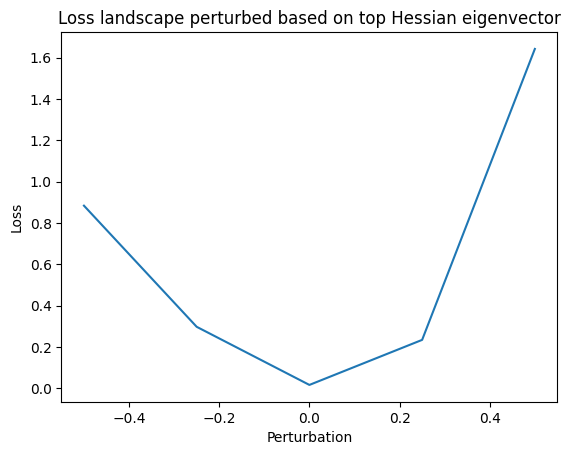

In [53]:
# lambda is a small scalar that we use to perturb the model parameters along the eigenvectors 
lams = np.linspace(-0.5, 0.5, 21).astype(np.float32)

loss_list = []

model_perb = torch.load(f=model_path, map_location=device)
model_perb = model_perb.to(dtype=torch.float32)

for lam in lams:
    model_perb = get_params(model, model_perb, top_eigenvector[0], lam)
    perb_output = model_perb(
        batch_dict,
        training=True,
        compute_force=True,
    )
    loss_list.append(criterion(pred=perb_output, ref = batch).item())

print(loss_list)
plt.plot(lams, loss_list)
plt.ylabel('Loss')
plt.xlabel('Perturbation')
plt.title('Loss landscape perturbed based on top Hessian eigenvector')

Now let's compare this with a loss landscape computed based on perturbing the model parameters along a random direction.

tensor([[  0,   0,   0,  ..., 335, 335, 335],
        [ 13,  16,  20,  ..., 300, 326, 306]])
tensor([[  0,   0,   0,  ..., 335, 335, 335],
        [ 13,  16,  20,  ..., 300, 326, 306]])
tensor([[  0,   0,   0,  ..., 335, 335, 335],
        [ 13,  16,  20,  ..., 300, 326, 306]])
tensor([[  0,   0,   0,  ..., 335, 335, 335],
        [ 13,  16,  20,  ..., 300, 326, 306]])
tensor([[  0,   0,   0,  ..., 335, 335, 335],
        [ 13,  16,  20,  ..., 300, 326, 306]])
tensor([[  0,   0,   0,  ..., 335, 335, 335],
        [ 13,  16,  20,  ..., 300, 326, 306]])
tensor([[  0,   0,   0,  ..., 335, 335, 335],
        [ 13,  16,  20,  ..., 300, 326, 306]])
tensor([[  0,   0,   0,  ..., 335, 335, 335],
        [ 13,  16,  20,  ..., 300, 326, 306]])
tensor([[  0,   0,   0,  ..., 335, 335, 335],
        [ 13,  16,  20,  ..., 300, 326, 306]])
tensor([[  0,   0,   0,  ..., 335, 335, 335],
        [ 13,  16,  20,  ..., 300, 326, 306]])
tensor([[  0,   0,   0,  ..., 335, 335, 335],
        [ 13,  16,  20, 

Text(0.5, 1.0, 'Loss landscape perturbed based on a random direction')

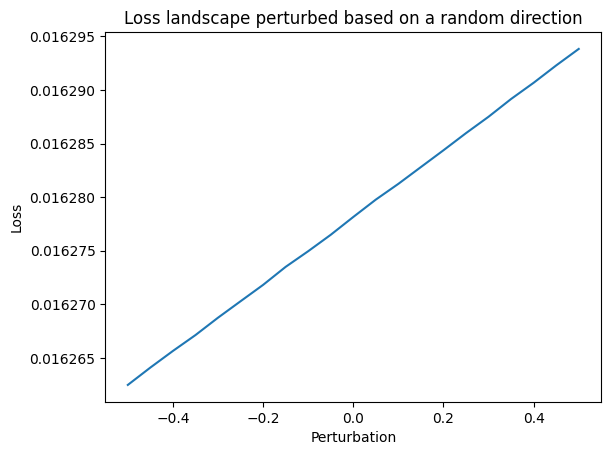

In [55]:
from pyhessian.utils import normalization

# generate random vector to do the loss plot

v = [torch.randn_like(p) for p in model.parameters()]
v = normalization(v)


# used to perturb your model 
lams = np.linspace(-0.5, 0.5, 21).astype(np.float32)

loss_list = []

# create a copy of the model
model_perb = torch.load(f=model_path, map_location=device)
model_perb = model_perb.to(dtype=torch.float32)

for lam in lams:
    model_perb = get_params(model, model_perb, v, lam)
    perb_output = model_perb(
        batch_dict,
        training=True,
        compute_force=True,
    )
    loss_list.append(criterion(pred=perb_output, ref = batch).item())

plt.plot(lams, loss_list)
plt.ylabel('Loss')
plt.xlabel('Perturbation')
plt.title('Loss landscape perturbed based on a random direction')

Note how different the loss landscape looks. In particular note that there is almost no change in the loss value (see the small scale of the y-axis). This is expected, since for a converged NN, many of the directions are typically degenarate (i.e. they are flat).

We can also use gradient direction to perturb the model. While gradient is better than random vector, but it is not possible to use it to plot 3D loss landscape since you will need more than one direction. However, you can use top 2 Hessian vectors instead for that scenario.

tensor([[  0,   0,   0,  ..., 335, 335, 335],
        [ 13,  16,  20,  ..., 300, 326, 306]])
tensor([[  0,   0,   0,  ..., 335, 335, 335],
        [ 13,  16,  20,  ..., 300, 326, 306]])
tensor([[  0,   0,   0,  ..., 335, 335, 335],
        [ 13,  16,  20,  ..., 300, 326, 306]])
tensor([[  0,   0,   0,  ..., 335, 335, 335],
        [ 13,  16,  20,  ..., 300, 326, 306]])
tensor([[  0,   0,   0,  ..., 335, 335, 335],
        [ 13,  16,  20,  ..., 300, 326, 306]])
tensor([[  0,   0,   0,  ..., 335, 335, 335],
        [ 13,  16,  20,  ..., 300, 326, 306]])
tensor([[  0,   0,   0,  ..., 335, 335, 335],
        [ 13,  16,  20,  ..., 300, 326, 306]])
tensor([[  0,   0,   0,  ..., 335, 335, 335],
        [ 13,  16,  20,  ..., 300, 326, 306]])
tensor([[  0,   0,   0,  ..., 335, 335, 335],
        [ 13,  16,  20,  ..., 300, 326, 306]])
tensor([[  0,   0,   0,  ..., 335, 335, 335],
        [ 13,  16,  20,  ..., 300, 326, 306]])
tensor([[  0,   0,   0,  ..., 335, 335, 335],
        [ 13,  16,  20, 

Text(0.5, 1.0, 'Loss landscape perturbed based on gradient direction')

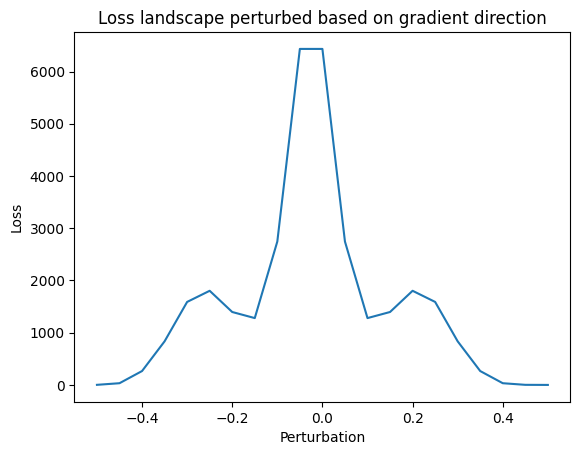

In [56]:
from pyhessian.utils import normalization


# used to perturb your model 
lams = np.linspace(-0.5, 0.5, 21).astype(np.float32)

loss_list = []

# create a copy of the model
model_perb = model

# generate gradient vector to do the loss plot
perb_output = model_perb(
    batch_dict,
    training=True,
    compute_force=True,
)

loss = criterion(pred=perb_output, ref=batch)
loss.backward()

v = [p.grad.data for p in model_perb.parameters()]
v = normalization(v)
model_perb.zero_grad()

for lam in lams: 
    model_perb = get_params(model, model_perb, v, lam)
    perb_output = model_perb(
    batch_dict,
    training=True,
    compute_force=True,
    )
    loss_list.append(criterion(pred=perb_output, ref=batch).item())

plt.plot(lams, loss_list)
plt.ylabel('Loss')
plt.xlabel('Perturbation')
plt.title('Loss landscape perturbed based on gradient direction')

## Example 3: Hessian Trace/Diagonal
We can also use randomized linear algebra to compute Hessian trace or approximate the Hessian diagonal with very little computational overhead. Let's first start with a numpy example, and then we will show results for a NN.

Now let's repeate the above for computing the trace and diagonal of Hessian for ResNet20.

In [60]:
trace = hessian_comp.trace()
print("The trace of this model is: %.4f"%(np.mean(trace)))

The trace of this model is: 14.0547


We can also get the full eigenvalue spectrum density of Hessian using Stochastic Lancoz algorithm.

In [61]:
density_eigen, density_weight = hessian_comp.density()

/Users/jerryho/Documents/PyHessian/density_plot.py:62: ComplexWarning: Casting complex values to real discards the imaginary part
  density_output[i, j] = np.sum(tmp_result * weights[i, :])


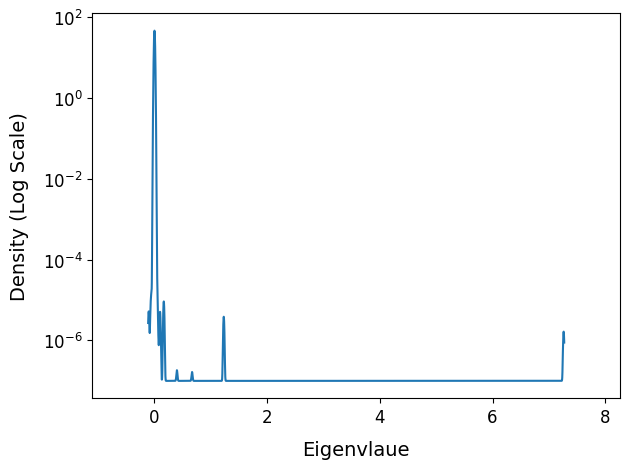

In [62]:
get_esd_plot(density_eigen, density_weight)

The above ESD plot is very interesting and shows that a lot of the eigenvalues of the Hessian are close to zero. This means that a lot of the directions along the loss landscape is almost flat. We expect this based on the loss landscape that we got above when we used a random direction. Another interesting observation is that there are several large Hessian outliers. The other very interesting finding, is that there are a lot of directions with slight negative curvature. This means that we still have not converged to a perfect local minimum that satisfies first and second order optimality conditions.